# Data Understanding
* 22 patient (23 case) - 664 EDF File
* 129 file has seizure (198 in total seizure)
* Sample rate: 256Hz
* 16bit
* Mostly 23 EEG
* Mostly 1 hour recording, some of them are 2-4 hours
* Seizure start/end timeline has been annotated

# Highly Important files :
* Subject-Info.txt -> patients info
* RECORDS.txt -> whole EDF list
* RECORDS-WITH-SEIZURES.txt -> seizure
* chbnn-summary.txt -> seizure

pip install mne numpy pandas scipy matplotlib seaborn scikit-learn

pip install pyedflib

In [95]:
import mne
import pandas as pd
import numpy as np
import utility.my_utils as utility
import matplotlib
#matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
import re
import os
import utility.my_utils as deniz



In [96]:
import warnings

warnings.filterwarnings("ignore")

In [97]:
one_case_1_data_path = "data/chb-mit/chb01/chb01_01.edf"
one_case_2_data_path = "data/chb-mit/chb01/chb01_02.edf"
one_case_3_data_path = "data/chb-mit/chb01/chb01_03.edf"
one_case_3_seizure_data_path = "data/chb-mit/chb01/chb01_03.edf.seizures"
edf_path = "data/chb-mit/chb01/chb01_01.edf"

# First Sight

* The channel names are not standard for each patient.

* There is a duplicate channel we need to take them in to a set so there will be unique data in each case 'T8-P8' so we will be checking for each and make every channel unique.

* We need to standardize the channel names.

In [ ]:
raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)

print(raw)
print("\nSampling rate:", raw.info['sfreq'])
print("Channels:", raw.ch_names)


### Checking how the channel lengths are named differently

In [ ]:
dataset_path = "data/chb-mit/"
deniz.channel_checking_rolling(dataset_path=dataset_path)

In [ ]:
dataset_path = "data/chb-mit/"
subject_folders = deniz.get_folder_names(dataset_path)
edf_path_05 = deniz.get_edf_paths(dataset_path,subject_folders[3])


In [ ]:
mne.io.read_raw_edf(edf_path_05[1])

In [ ]:
channels = []
for name in raw.ch_names:
    if name == 'T8-P8-1' or name == 'T8-P8-0':
        channels.append('T8-P8-1')
    else:
        # Only add the original name if it does not meet the above requirements
        channels.append(name)

unique_channels = sorted(list(set(channels)))
print(unique_channels)

In [ ]:
len(channels)

In [ ]:
raw.set_channel_types({ch: "eeg" for ch in channels})

In [ ]:
with open("data/chb-mit/RECORDS-WITH-SEIZURES") as f:
    seizure_files = [line.strip() for line in f]

seizure_files[:5], len(seizure_files)

* 142 total seizures file but there might be more than one seizures in a single file.

### Let's check some files with seizures. Is there something possible to see ?


In [ ]:
edf_path_0 = ('data/chb-mit/' + str(seizure_files[0]))
edf_path_1 = ('data/chb-mit/' + str(seizure_files[1]))
edf_path_2 = ('data/chb-mit/' + str(seizure_files[2]))
raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
raw1 = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
raw2 = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)

raw.plot(

    n_channels=23,
    scalings="auto"
),

raw1.plot(
    n_channels=23,
    scalings="auto")
,
raw2.plot(
    n_channels=23,
    scalings="auto",

);

### Let's make sure in which seconds the seizures occurred. We can verify the seizure time from the chbXX_summary.txt files.

In [ ]:
edf_path_0_summary = "data/chb-mit/chb01/chb01-summary.txt"
summary_edf01 = open(edf_path_0_summary)

In [ ]:
summary_edf01.read()

* File Name: chb01_03.edf
* File Start Time: 13:43:04
* File End Time: 14:43:04
* Number of Seizures in File: 1
* Seizure Start Time: 2996 seconds
* Seizure End Time: 3036 seconds
----
* File Name: chb01_04.edf
* File Start Time: 14:43:12
* File End Time: 15:43:12
* Number of Seizures in File: 1
* Seizure Start Time: 1467 seconds
* Seizure End Time: 1494 seconds
----
* File Name: chb01_15.edf
* File Start Time: 01:44:44
* File End Time: 2:44:44
* Number of Seizures in File: 1
* Seizure Start Time: 1732 seconds
* Seizure End Time: 1772 seconds

### Now we know that in which seconds there is seizure so we may look up to signals and we might see some abnormal activity and if there's some abnormal activity it means somehow we may achieve to classify or even further we might make some prediction.

In [ ]:
raw.plot(
    duration=10,
    n_channels=23,
    scalings="auto",
    start=2990,
);
raw1.plot(
    duration=10,
    n_channels=23,
    scalings="auto",
    start=1460,
);
raw2.plot(
    duration=10,
    n_channels=23,
    scalings="auto",
    start=1730,
);

### As the images show, just in the start of the seizures the graph gets many spikes upside down than the usual, wave lengths getting smaller afterwards (we will be experimenting that in the upcoming in those graphs these are not seem to be clear).

# Exploring the Dataset

In [ ]:
try:
    # Load the EDF file
    raw = mne.io.read_raw_edf(one_case_1_data_path, preload=True, verbose='warning')
    print(f"Successfully loaded EDF file: {one_case_1_data_path}")

    # Inspect the data
    print("\n--- Raw Info ---")
    print(raw.info)

    print("\n--- Channel Names ---")
    print(raw.ch_names[:10]) # Print first 10 channel names
    if len(raw.ch_names) > 10:
        print(f"... and {len(raw.ch_names) - 10} more channels")

    print("\n--- Data Shape (channels, samples) ---")
    print(raw.get_data().shape)

    print("\n--- Sample Frequency ---")
    print(f"{raw.info['sfreq']} Hz")


except Exception as e:
    print(f"An error occurred: {e}")

In [ ]:
raw.times[-1]

In [ ]:
log_durations = np.array([s['log_duration'] for s in all_samples])
unique_patients = sorted(set(s['patient'] for s in all_samples))

# 2. Correctly initialize Figure and Axes together
fig, ax1 = plt.subplots(figsize=(12, 10))

# 3. Calculate means and standard deviations
patient_log_means = [np.mean([np.log(s['duration']) for s in all_samples if s['patient'] == p]) for p in unique_patients]
patient_log_stds = [np.std([np.log(s['duration']) for s in all_samples if s['patient'] == p]) for p in unique_patients]
sort_idx = np.argsort(patient_log_means)

# 4. Plot on ax1
ax1.errorbar(range(len(unique_patients)),
             [patient_log_means[i] for i in sort_idx],
             yerr=[patient_log_stds[i] for i in sort_idx],
             fmt='o', capsize=3, alpha=0.7, color='purple')

ax1.set_xlabel('Patient (sorted by mean log duration)')
ax1.set_ylabel('Log Duration')
ax1.set_title('Log Duration by Patient')

# Set ticks correctly
ax1.set_xticks(range(len(unique_patients)))
ax1.set_xticklabels([unique_patients[i] for i in sort_idx], rotation=45)

ax1.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Read Seizure Annotations

In [ ]:
chb_01_dot = "data/chb-mit/chb01"
edf_path_0_summary = edf_path_0_summary


def parse_summary_text(summary_path):
    """
    Parses the standard chbXX-summary.txt file to extract seizure times.
    Returns a dictionary: { 'filename.edf': [(start, end), (start, end)] }
    """
    seizure_map = {}
    current_file = None

    with open(summary_path, 'r') as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect Filename
        if line.startswith("File Name:"):
            current_file = line.split("File Name:")[1].strip()
            if current_file not in seizure_map:
                seizure_map[current_file] = []

        # Detect Seizure Times (Standard CHB format)
        if "Seizure" in line and "Start Time" in line:
            try:
                # Extract the start time
                start_sec = int(re.search(r':\s*(\d+)\s*seconds', line).group(1))

                # Look ahead to the next line for End Time
                next_line = lines[i + 1].strip()
                end_sec = int(re.search(r':\s*(\d+)\s*seconds', next_line).group(1))

                seizure_map[current_file].append((start_sec, end_sec))
            except (AttributeError, IndexError, ValueError):
                continue

    return seizure_map

In [ ]:
summary_parsed = parse_summary_text(edf_path_0_summary)
summary_parsed

###  Parse All Seizure Annotations

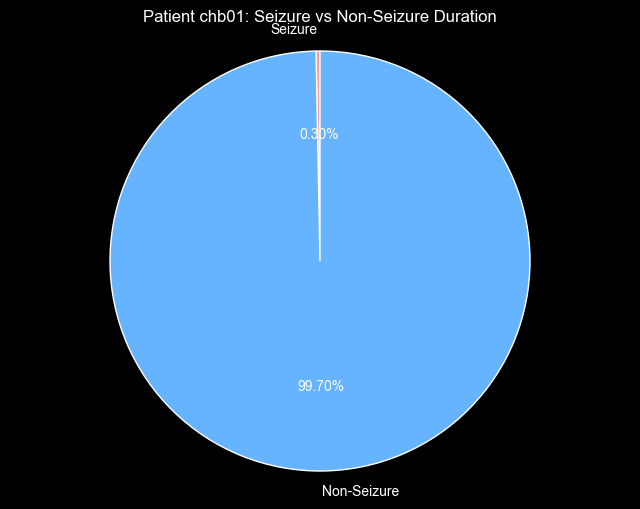

In [76]:
# Parse annotations

print(f"Parsing summary file: {edf_path_0_summary}")
try:
    file_seizures = parse_summary_text(edf_path_0_summary)
except FileNotFoundError:
    print("Error: chb01-summary.txt not found. Please check your chb_01 path.")
    file_seizures = {}

total_seizure_duration = 0
total_non_seizure_duration = 0

# Get list of EDF files in directory
edf_files = sorted([f for f in os.listdir(chb_01_dot) if f.endswith('.edf')])

print(f"Processing {len(edf_files)} EDF files...")

for edf_filename in edf_files:
    edf_path = os.path.join(chb_01_dot, edf_filename)

    try:
        raw = mne.io.read_raw_edf(edf_path, preload=False, verbose='error')

        # Get total file duration
        edf_duration = raw.times[-1]

        # Calculate seizure duration for this specific file
        current_seizure_dur = 0
        if edf_filename in file_seizures:
            for start, end in file_seizures[edf_filename]:
                current_seizure_dur += (end - start)

        # Calculate non-seizure
        current_non_seizure_dur = edf_duration - current_seizure_dur

        # Accumulate totals
        total_seizure_duration += current_seizure_dur
        total_non_seizure_duration += current_non_seizure_dur

    except Exception as e:
        print(f"Error processing {edf_filename}: {e}")

# Plotting the Results

total_duration = total_seizure_duration + total_non_seizure_duration
seizure_pct = (total_seizure_duration / total_duration) * 100
non_seizure_pct = (total_non_seizure_duration / total_duration) * 100

print(f"\n--- Results for Patient chb01 ---")
print(f"Total Seizure: {total_seizure_duration:.2f}s ({seizure_pct:.2f}%)")
print(f"Total Non-Seizure: {total_non_seizure_duration:.2f}s ({non_seizure_pct:.2f}%)")

# Create Pie Chart
labels = ['Seizure', 'Non-Seizure']
percentages = [seizure_pct, non_seizure_pct]
colors = ['#ff9999', '#66b3ff']  # Red for seizure, Blue for normal

plt.figure(figsize=(8, 6))
plt.pie(percentages, labels=labels, colors=colors, autopct='%1.2f%%', startangle=90)
plt.title('Patient chb01: Seizure vs Non-Seizure Duration')
plt.axis('equal')
plt.show()

### Every seizure included in each edf file's corresponding seizure file as start and stop seconds


In [77]:
dataset_path = "data/chb-mit/"
folder_name = deniz.get_folder_names(dataset_path)

summary_path = f"{dataset_path}/{folder_name[16]}/{folder_name[16]}-summary.txt"

df = deniz.parse_chb_summary(summary_path, folder_name[16])
df

,folder,file,seizure_start_sec,seizure_end_sec
0,chb17,chb17a_03.edf,2282,2372
1,chb17,chb17a_04.edf,3025,3140
2,chb17,chb17b_63.edf,3136,3224


In [78]:
dataset_path = "data/chb-mit/"
subject_folders=deniz.get_folder_names(dataset_path)
df

,folder,file,seizure_start_sec,seizure_end_sec
0,chb17,chb17a_03.edf,2282,2372
1,chb17,chb17a_04.edf,3025,3140
2,chb17,chb17b_63.edf,3136,3224


In [79]:
dataset_path = "data/chb-mit/"
df_seizures=deniz.build_seizure_dataframe(dataset_path)
df_seizures

,folder,file,seizure_start_sec,seizure_end_sec
0,chb01,chb01_03.edf,2996,3036
1,chb01,chb01_04.edf,1467,1494
2,chb01,chb01_15.edf,1732,1772
3,chb01,chb01_16.edf,1015,1066
4,chb01,chb01_18.edf,1720,1810
...,...,...,...,...
193,chb24,chb24_13.edf,3288,3304
194,chb24,chb24_14.edf,1939,1966
195,chb24,chb24_15.edf,3552,3569
196,chb24,chb24_17.edf,3515,3581


In [80]:
df_seizures[df_seizures['folder']== subject_folders[16]]

,folder,file,seizure_start_sec,seizure_end_sec
148,chb17,chb17a_03.edf,2282,2372
149,chb17,chb17a_04.edf,3025,3140
150,chb17,chb17b_63.edf,3136,3224


In [81]:
df_seizures[df_seizures['file'] == 'chb17a_03.edf']

,folder,file,seizure_start_sec,seizure_end_sec
148,chb17,chb17a_03.edf,2282,2372


In [82]:
single_edf = f"{dataset_path}/{folder_name[3]}/{folder_name[3]}_01.edf"
print(mne.io.read_raw_edf(single_edf, preload=False).ch_names)

['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']


In [83]:
raw=mne.io.read_raw_edf(single_edf, preload=False)

Creating raw.info structure...


### How to build epochs as sliding windows over the continuous raw file?

In [84]:
events = mne.make_fixed_length_events(raw, id=1, duration=2.0)

In [85]:
events

array([[      0,       0,       1],
       [    512,       0,       1],
       [   1024,       0,       1],
       ...,
       [3684352,       0,       1],
       [3684864,       0,       1],
       [3685376,       0,       1]])

In [86]:
single_edf = f"{dataset_path}/{folder_name[22]}/{folder_name[22]}_06.edf"
raw = mne.io.read_raw_edf(single_edf, preload=False)


Creating raw.info structure...


### Visualize seizure vs. non-seizure

In [87]:
# ============================================
# CELL 7: Visualize Normal vs Seizure - WITH FILE SAVE
# ============================================

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import mne
from pathlib import Path

# Configure matplotlib
%matplotlib inline
plt.close('all')

edf_file_path = "data/chb-mit/chb01/chb01_03.edf"

print("="*60)
print("📈 VISUALIZING NORMAL vs SEIZURE ACTIVITY")
print("="*60)

# Load the EDF file
print("\n📂 Loading EDF file...")
raw = mne.io.read_raw_edf(edf_file_path, preload=True, verbose=False)
signals = raw.get_data()
channel_names = raw.ch_names
fs = int(raw.info['sfreq'])
print(f"✅ Loaded: {len(channel_names)} channels, sampling rate: {fs} Hz")

# Select channels to display
n_display_channels = min(8, len(channel_names))

# Define time windows (in seconds)
normal_start = 1000
normal_end = 1010
seizure_start_time = 2996
seizure_end_time = 3036

seizure_vis_start = seizure_start_time - 5
seizure_vis_end = seizure_end_time + 15

# Convert to samples
normal_start_samp = normal_start * fs
normal_end_samp = normal_end * fs
seizure_start_samp = seizure_vis_start * fs
seizure_end_samp = seizure_vis_end * fs

# Create figure
print("\n🎨 Creating visualization...")
fig, axes = plt.subplots(2, 1, figsize=(14, 10), dpi=100)

# ===== Plot 1: Normal Activity =====
ax1 = axes[0]
time_normal = np.arange(normal_end_samp - normal_start_samp) / fs

for i in range(n_display_channels):
    signal_segment = signals[i, normal_start_samp:normal_end_samp]
    signal_norm = (signal_segment - np.mean(signal_segment)) / (np.std(signal_segment) + 1e-8)
    ax1.plot(time_normal, signal_norm + i*5, linewidth=0.5, label=channel_names[i])

ax1.set_title('🧠 NORMAL Brain Activity (No Seizure)', fontsize=14, fontweight='bold', color='green')
ax1.set_xlabel('Time (seconds)', fontsize=12)
ax1.set_ylabel('Channels (normalized + offset)', fontsize=12)
ax1.set_xlim(0, 10)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=8, ncol=2)

# ===== Plot 2: Seizure Activity =====
ax2 = axes[1]
time_seizure = np.arange(seizure_end_samp - seizure_start_samp) / fs

for i in range(n_display_channels):
    signal_segment = signals[i, seizure_start_samp:seizure_end_samp]
    signal_norm = (signal_segment - np.mean(signal_segment)) / (np.std(signal_segment) + 1e-8)
    ax2.plot(time_seizure, signal_norm + i*5, linewidth=0.5)

# Mark seizure onset
ax2.axvline(x=5, color='red', linestyle='--', linewidth=2, label='Seizure Onset')
ax2.axvspan(5, 20, alpha=0.2, color='red', label='Seizure Period')

ax2.set_title('🚨 SEIZURE Activity (Abnormal Patterns)', fontsize=14, fontweight='bold', color='red')
ax2.set_xlabel('Time (seconds)', fontsize=12)
ax2.set_ylabel('Channels (normalized + offset)', fontsize=12)
ax2.set_xlim(0, 20)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right', fontsize=10)

plt.tight_layout()

# Save to file as backup
output_dir = Path("visualizations")
output_dir.mkdir(exist_ok=True)
output_file = output_dir / "seizure_comparison.png"
plt.savefig(output_file, dpi=150, bbox_inches='tight')
print(f"\n💾 Plot saved to: {output_file}")

# Display in notebook
plt.show()

print("\n📊 Key Observations:")
print("   • Normal: Regular, low-amplitude patterns")
print("   • Seizure: High-amplitude, rhythmic, abnormal spikes")
print("   • The model will learn to detect these differences!")

print("\n" + "="*60)
print("✅ Visualization complete!")
print(f"📁 If plot doesn't display above, check: {output_file}")
print("="*60)


📊 Key Observations:
   • Normal: Regular, low-amplitude patterns
   • Seizure: High-amplitude, rhythmic, abnormal spikes
   • The model will learn to detect these differences!

✅ Visualization complete!
📁 If plot doesn't display above, check: visualizations\seizure_comparison.png


### Display the standardized channels

In [88]:
# Detecting bad channels
seizured_files_dataset_path = "../seizured_files"
subject_folders = deniz.get_folder_names(seizured_files_dataset_path)
every_path = deniz.get_edf_paths(seizured_files_dataset_path, subject_folders)

for i in every_path:
    raw = mne.io.read_raw_edf(i, verbose=False, preload=False)
    print(raw.info["bads"])
# Verify channel standardization
print(raw.info['ch_names'])

['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']


In [89]:
single_edf = f"{dataset_path}/{folder_name[22]}/{folder_name[22]}_06.edf"
raw = mne.io.read_raw_edf(single_edf, preload=False)

Creating raw.info structure...


### Detecting bad channels


In [90]:
dataset_path = "data/chb-mit/"
subject_folders = deniz.get_folder_names(dataset_path)
every_path = deniz.get_edf_paths(dataset_path, subject_folders)


for i in every_path:
    raw = mne.io.read_raw_edf(i,verbose=False, preload=False)
    print(raw.info["bads"])

[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]


In [91]:
raw

<RawEDF | chb24_22.edf, 23 x 273152 (1067.0 s), ~27 KiB, data not loaded>

In [92]:
raw.crop(tmin=0, tmax=3).load_data()

<RawEDF | chb24_22.edf, 23 x 769 (3.0 s), ~165 KiB, data loaded>

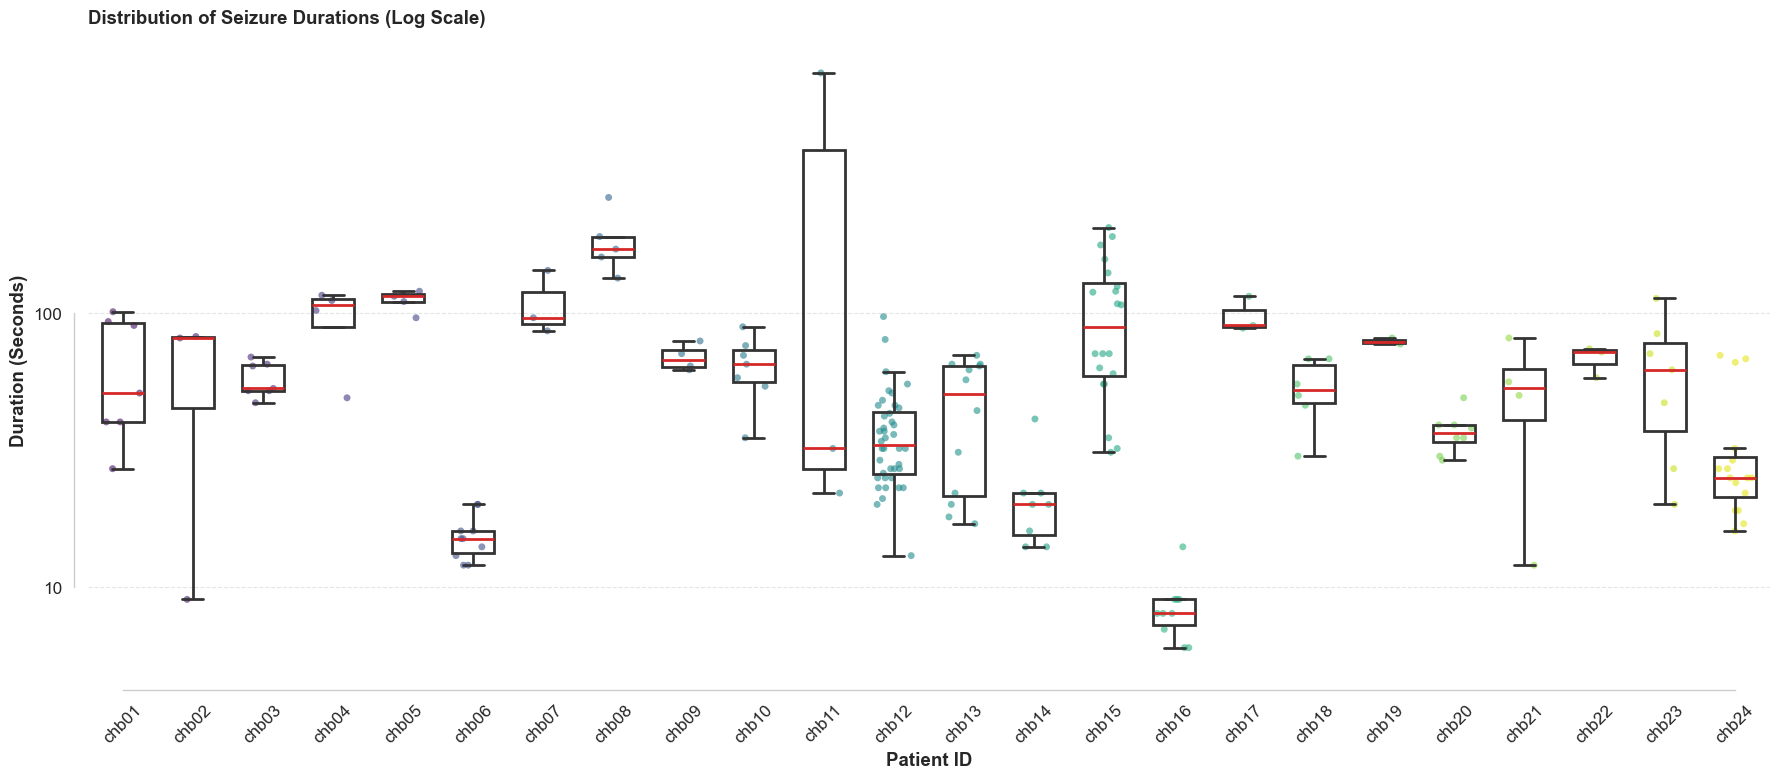

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import mne
import re
from matplotlib.ticker import ScalarFormatter

# =========================================================
# 1. DEFINE THE PARSER FUNCTION (Missing Piece)
# =========================================================
def parse_summary_text(summary_path):
    """
    Parses a CHB-MIT summary text file to extract seizure start/end times.
    Returns a dict: {'filename.edf': [(start_sec, end_sec), ...]}
    """
    seizures = {}
    current_file = None

    with open(summary_path, 'r') as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect Filename
        if line.startswith("File Name:"):
            current_file = line.split("File Name:")[1].strip()
            if current_file not in seizures:
                seizures[current_file] = []

        # Detect Seizure Times
        # Format usually: "Seizure 1 Start Time: 123 seconds"
        elif "Seizure" in line and "Start Time" in line:
            try:
                start_sec = int(re.search(r':\s*(\d+)\s*seconds', line).group(1))
                # Look ahead for end time (usually next line or two)
                end_line = lines[i+1].strip()
                if "End Time" in end_line:
                    end_sec = int(re.search(r':\s*(\d+)\s*seconds', end_line).group(1))
                    seizures[current_file].append((start_sec, end_sec))
            except (AttributeError, ValueError, IndexError):
                continue

    return seizures

# =========================================================
# 2. DATA COLLECTION
# =========================================================
base_dir = 'C:\\Users\\gorse\\OneDrive - TUNI.fi\\Desktop\\Tez\\uvtez\\data\\chb-mit\\'

all_seizure_durations = []

# Get patient directories
try:
    patient_dirs = sorted([d for d in os.listdir(base_dir)
                           if os.path.isdir(os.path.join(base_dir, d)) and d.startswith('chb')])
except FileNotFoundError:
    print(f"Error: Directory not found at {base_dir}")
    patient_dirs = []

if patient_dirs:
    print(f"Processing {len(patient_dirs)} patients...")

    for patient_id in patient_dirs:
        patient_dir = os.path.join(base_dir, patient_id)
        summary_file = os.path.join(patient_dir, f"{patient_id}-summary.txt")

        # 1. Parse annotations
        if os.path.exists(summary_file):
            file_seizures = parse_summary_text(summary_file)
        else:
            print(f"Summary file missing for {patient_id}")
            continue

        # 2. Process seizure data
        for edf_filename, seizure_list in file_seizures.items():
            for start, end in seizure_list:
                duration = end - start

                # Filter out negative or zero durations (sanity check)
                if duration > 0:
                    all_seizure_durations.append({
                        'Patient ID': patient_id,
                        'File': edf_filename,
                        'Seizure Duration (s)': duration
                    })

# =========================================================
# 3. VISUALIZATION
# =========================================================

# Create DataFrame
df_seizures = pd.DataFrame(all_seizure_durations)

if not df_seizures.empty:
    print(f"Plotting {len(df_seizures)} seizure events...")

    patient_order = sorted(df_seizures['Patient ID'].unique())

    # Set theme
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
    plt.figure(figsize=(18, 8))
    ax1 = plt.gca()

    # 1. Strip Plot (Individual Dots)
    sns.stripplot(
        data=df_seizures,
        x='Patient ID',
        y='Seizure Duration (s)',
        ax=ax1,
        order=patient_order,
        palette='viridis',
        size=5,
        alpha=0.6,
        jitter=0.25,
        zorder=0
    )

    # 2. Box Plot (Statistics)
    sns.boxplot(
        data=df_seizures,
        x='Patient ID',
        y='Seizure Duration (s)',
        ax=ax1,
        order=patient_order,
        showfliers=False,
        width=0.6,
        linewidth=2,
        boxprops=dict(facecolor="none", edgecolor="#333333", zorder=1),
        whiskerprops=dict(color="#333333", linewidth=2),
        capprops=dict(color="#333333", linewidth=2),
        medianprops=dict(color="#D62828", linewidth=2)
    )

    # Scaling and Styling
    ax1.set_yscale('log')
    ax1.yaxis.set_major_formatter(ScalarFormatter())

    ax1.set_title('Distribution of Seizure Durations (Log Scale)', loc='left', fontweight='bold', pad=15)
    ax1.set_ylabel('Duration (Seconds)', fontweight='bold')
    ax1.set_xlabel('Patient ID', fontweight='bold')

    ax1.grid(axis='y', linestyle='--', alpha=0.5, which='major')
    ax1.tick_params(axis='x', rotation=45)

    sns.despine(offset=10, trim=True)
    plt.tight_layout()
    plt.show()

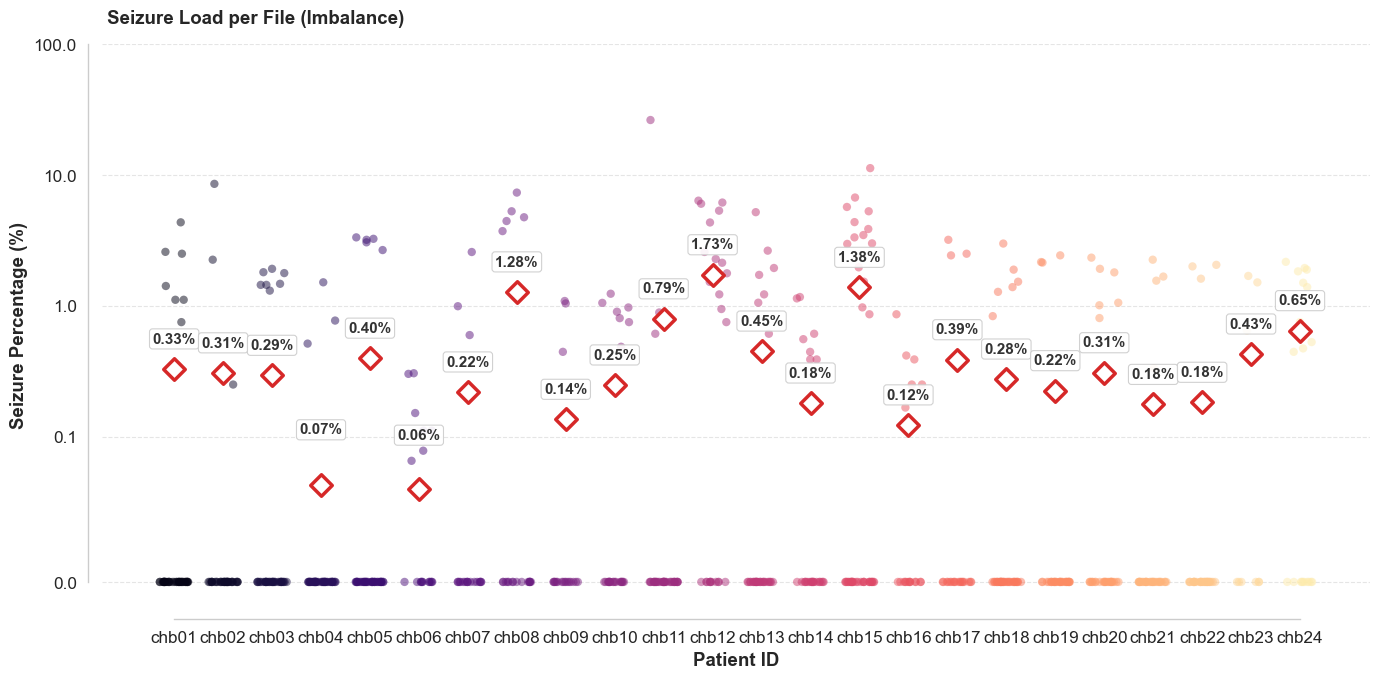

In [100]:
# ---------------------------------------------------------
# 1. SETUP AND DATA LOADING
# ---------------------------------------------------------
base_dir = 'C:\\Users\\gorse\\OneDrive - TUNI.fi\\Desktop\\Tez\\uvtez\\data\\chb-mit\\'

# Get patient directories
try:
    patient_dirs = sorted([d for d in os.listdir(base_dir)
                           if os.path.isdir(os.path.join(base_dir, d)) and d.startswith('chb')])
except FileNotFoundError:
    print(f"Directory not found: {base_dir}")
    patient_dirs = []

data_durations = []
data_percentages = []

if patient_dirs:
    print(f"Processing {len(patient_dirs)} patients...")

    for patient_id in patient_dirs:
        patient_dir = os.path.join(base_dir, patient_id)
        summary_file = os.path.join(patient_dir, f"{patient_id}-summary.txt")

        try:
            # Check if parse_summary_text exists, otherwise skip or define it
            if 'parse_summary_text' in globals():
                file_seizures = parse_summary_text(summary_file)
            else:
                # Placeholder if function is missing in this context
                continue
        except Exception:
            continue

        edf_files = sorted([f for f in os.listdir(patient_dir) if f.endswith('.edf')])

        for edf_filename in edf_files:
            edf_path = os.path.join(patient_dir, edf_filename)

            try:
                # Read EDF header
                raw = mne.io.read_raw_edf(edf_path, preload=False, verbose='error')
                edf_duration = raw.times[-1]

                file_seizure_dur_total = 0

                # --- COLLECT DATA ---
                if edf_filename in file_seizures:
                    for start, end in file_seizures[edf_filename]:
                        duration = end - start
                        file_seizure_dur_total += duration

                        data_durations.append({
                            'Patient ID': patient_id,
                            'Seizure Duration (s)': duration
                        })

                if edf_duration > 0:
                    pct = (file_seizure_dur_total / edf_duration) * 100
                    data_percentages.append({
                        'Patient ID': patient_id,
                        'Seizure Percentage': pct
                    })

            except Exception as e:
                # print(f"  Error {edf_filename}: {e}")
                continue

# ---------------------------------------------------------
# 2. PLOTTING (The Fix)
# ---------------------------------------------------------

# FIX 1: Create the correct DataFrame for percentages
df_files = pd.DataFrame(data_percentages)

if not df_files.empty:

    # Ensure consistent order
    patient_order = sorted(df_files['Patient ID'].unique())

    # Create the figure
    plt.figure(figsize=(14, 7))
    ax2 = plt.gca() # Get current axis

    # FIX 2: Use df_files here (not df_seizures)
    sns.stripplot(
        data=df_files,
        x='Patient ID',
        y='Seizure Percentage',
        ax=ax2,
        order=patient_order,
        palette='magma',
        size=6,
        alpha=0.5,
        jitter=0.3,
        zorder=1
    )

    # 2. Add Mean Markers
    # FIX 3: Use df_files here too
    pct_means = df_files.groupby('Patient ID')['Seizure Percentage'].mean().reindex(patient_order)

    ax2.scatter(
        range(len(patient_order)), pct_means,
        color='white', s=120, marker='D', zorder=3, edgecolors='#D62828', linewidth=2.5, label='Mean %'
    )

    # 3. Add Text Labels for Means
    for x, val in enumerate(pct_means):
        if pd.notna(val):
            ax2.text(
                x, val * 1.5 if val > 0 else 0.1,
                f"{val:.2f}%",
                ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='#333',
                bbox=dict(facecolor='white', alpha=0.9, edgecolor='#ccc', boxstyle='round,pad=0.2')
            )

    # 4. SymLog Scale
    ax2.set_yscale('symlog', linthresh=0.1)
    ax2.set_yticks([0, 0.1, 1, 10, 100])
    ax2.get_yaxis().set_major_formatter(ScalarFormatter())

    ax2.set_title(' Seizure Load per File (Imbalance)', loc='left', fontweight='bold', pad=15)
    ax2.set_ylabel('Seizure Percentage (%)', fontweight='bold')
    ax2.set_xlabel('Patient ID', fontweight='bold')
    ax2.grid(axis='y', linestyle='--', alpha=0.5)

    plt.sca(ax2)
    plt.xticks(rotation=45, ha='right')
    sns.despine(offset=10, trim=True)
    plt.tight_layout()
    plt.show()